## Question 

## Does addiction affect how you like your steak prepared?

## My sudy is a census study b/c I am observing if they have an addiction and what steak they like the most and seeing how that corrlates to others. but I am not taking the full population because some people said they dont like steak so they are left out.

In [31]:
import pandas as pd

In [32]:
df = pd.read_csv("steak.csv")

In [33]:
df["Addictions"] = ((df["Do you ever smoke cigarettes?"] == "Yes") | (df["Do you ever drink alcohol?"] == "Yes") | (df["Do you ever gamble?"] == "Yes"))

In [34]:
Steak_data = df[
    (df["Do you eat steak?"] == "Yes") & 
    (df["How do you like your steak prepared?"].notna())]

In [35]:
table = pd.crosstab(Steak_data["Addictions"], Steak_data["How do you like your steak prepared?"])

In [36]:
print(table)

How do you like your steak prepared?  Medium  Medium Well  Medium rare  Rare  \
Addictions                                                                     
False                                     15           11           27     1   
True                                     117           63          139    22   

How do you like your steak prepared?  Well  
Addictions                                  
False                                    7  
True                                    28  


In [37]:
percentage_table = pd.crosstab(Steak_data["Addictions"], Steak_data["How do you like your steak prepared?"], normalize="index") * 100

In [38]:
percentage_table.index = ["No Addiction", "Addiction"]

In [39]:
percentage_table = percentage_table.round(1).astype(str) + "%"

In [40]:
print(percentage_table.T)

                                     No Addiction Addiction
How do you like your steak prepared?                       
Medium                                      24.6%     31.7%
Medium Well                                 18.0%     17.1%
Medium rare                                 44.3%     37.7%
Rare                                         1.6%      6.0%
Well                                        11.5%      7.6%


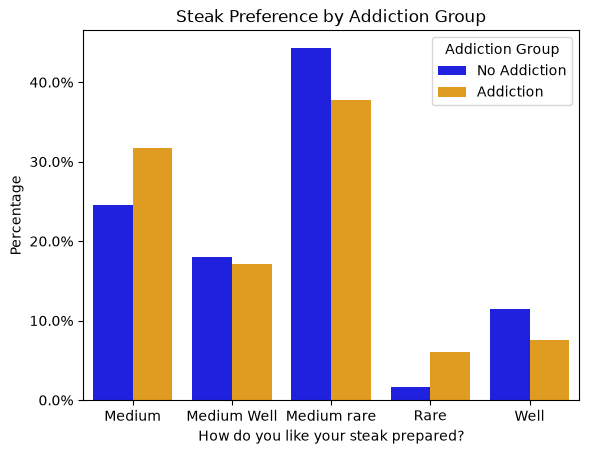

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Turn percentage_table into graphable data
graph_data = percentage_table.T.reset_index()

graph_data = graph_data.melt(
    id_vars="How do you like your steak prepared?",
    var_name="Addiction Group",
    value_name="Percentage"
)

# Remove the % sign and convert to numbers
graph_data["Percentage"] = (
    graph_data["Percentage"]
    .astype(str)
    .str.rstrip("%")
    .astype(float)
)

# Create side-by-side bar graph
sns.barplot(
    data=graph_data,
    x="How do you like your steak prepared?",
    y="Percentage",
    hue="Addiction Group",
    palette={
        "No Addiction": "blue",
        "Addiction": "orange"
    }
)

# Make y-axis display percentages
plt.gca().yaxis.set_major_formatter(PercentFormatter(100))

plt.ylabel("Percentage")
plt.xlabel("How do you like your steak prepared?")
plt.title("Steak Preference by Addiction Group")
plt.show()

## Conclusion
my conclusion is that addiction does affect how people like there steak prepared. People without addiction most commonly preffered medium rare steaks at 44.3% while people with addiction only preffered is 37.7% which is a differnce in my findings and is something I did not expect to find.

## My graph
My graph was able to help me interprete the true differnce in the numbers. with just the precentages it is tough to truly understand the differnces but with the graph you can see all the up and downs that are found in the data.